In [5]:
from pathlib import Path
import sys

# Project root
PROJECT_ROOT = Path.cwd().resolve().parent

# Bronze layer path
BRONZE_PATH = PROJECT_ROOT / "bronze_layer"

# Add project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Add bronze_layer folder
if str(BRONZE_PATH) not in sys.path:
    sys.path.insert(0, str(BRONZE_PATH))

In [6]:
import pandas as pd

from ingest import load_raw_data
from config import RAW_DATA_PATH

### Phase 1: Dataset Inventory

The purpose of this phase is to answer one question:

"What data do we actually have?"
Summarize the datasets ingested from the Bronze layer to verify completeness and 
understand their characteristics before designing Silver transformations.

In [ ]:
datasets = load_raw_data()
inventory = []

for dataset_name, df in datasets.items():

    city, day_type = dataset_name.rsplit("_", 1) #splits only once from the right.

    inventory.append(
        {
            "Dataset": dataset_name,
            "City": city.title(), #.title() is a string method in Python that capitalizes the first letter of each word
            "Day Type": day_type.title(),
            "Rows": len(df),
            "Columns": df.shape[1],
            "Memory (KB)": round(df.memory_usage(deep=True).sum() / 1024, 2)
        }
    )

inventory_df = (
    pd.DataFrame(inventory)
      .sort_values(["City", "Day Type"])
      .reset_index(drop=True)
)

inventory_df

,Dataset,City,Day Type,Rows,Columns,Memory (KB)
0,amsterdam_weekdays,Amsterdam,Weekdays,1103,20,208.51
1,amsterdam_weekends,Amsterdam,Weekends,977,20,185.04
2,athens_weekdays,Athens,Weekdays,2653,20,504.73
3,athens_weekends,Athens,Weekends,2627,20,499.79
4,barcelona_weekdays,Barcelona,Weekdays,1555,20,292.74
5,barcelona_weekends,Barcelona,Weekends,1278,20,240.28
6,berlin_weekdays,Berlin,Weekdays,1284,20,242.23
7,berlin_weekends,Berlin,Weekends,1200,20,226.29
8,budapest_weekdays,Budapest,Weekdays,2074,20,394.42
9,budapest_weekends,Budapest,Weekends,1948,20,370.46


In [ ]:
print(f"Total datasets: {len(inventory_df)}")
print(f"Total cities: {inventory_df['City'].nunique()}")
print(f"Total listings: {inventory_df['Rows'].sum():,}")
print(f"Largest dataset: {inventory_df.loc[inventory_df['Rows'].idxmax(), 'Dataset']}") #return the index (row label) of the maximum value
print(f"Smallest dataset: {inventory_df.loc[inventory_df['Rows'].idxmin(), 'Dataset']}")

Total datasets: 20
Total cities: 10
Total listings: 51,707
Largest dataset: london_weekends
Smallest dataset: amsterdam_weekends


### Phase 2 — Schema Consistency

Verify that all datasets share a consistent structure before they are combined or transformed in the Silver layer.

Schema consistency is one of the most important requirements in any ETL pipeline. Even if datasets appear similar, differences in column names, ordering, or data types can cause incorrect merges, transformation errors, or inaccurate analytics.
## Why This Matters

Imagine one dataset contains:

- `realSum`

while another contains:

- `price`

Both represent the same business concept, but a merge would produce two separate columns instead of one.

Similarly, inconsistent data types (e.g., `int64` vs `float64`) can lead to unexpected behavior during calculations and aggregations.

Identifying these inconsistencies early allows us to standardize the data before implementing the Silver layer.

Phase 2.1 — Column Names

The first question:

Do all datasets contain exactly the same columns?

We already know Bronze said yes.

Now we want evidence.

Instead of comparing every dataset with every other dataset, we'll compare all datasets against the first one.

Why?

Because if dataset A matches the reference,
dataset B matches the reference,
dataset C matches the reference...

then they all match each other.

This reduces the problem from:

20 × 19 comparisons

to

19 comparisons

A much more efficient approach.

In [10]:
# Use the first dataset as the reference schema
reference_dataset = next(iter(datasets))
reference_columns = datasets[reference_dataset].columns

print(f"Reference Dataset: {reference_dataset}")
print(f"Number of Columns: {len(reference_columns)}")

Reference Dataset: amsterdam_weekdays
Number of Columns: 20


In [11]:
schema_results = []

for dataset_name, df in datasets.items():

    matches = reference_columns.equals(df.columns)

    schema_results.append(
        {
            "Dataset": dataset_name,
            "Matches Reference": matches
        }
    )

schema_df = pd.DataFrame(schema_results)

schema_df

,Dataset,Matches Reference
0,amsterdam_weekdays,True
1,amsterdam_weekends,True
2,athens_weekdays,True
3,athens_weekends,True
4,barcelona_weekdays,True
5,barcelona_weekends,True
6,berlin_weekdays,True
7,berlin_weekends,True
8,budapest_weekdays,True
9,budapest_weekends,True


### 2.2 Verify that all datasets store their columns in the same order.

In [ ]:
column_order_results = []

for dataset_name, df in datasets.items():

    column_order_results.append({
        "Dataset": dataset_name,
        "Column Order Matches": reference_columns.equals(df.columns) # we didnt use == bec it compares each column and return a list [true,false...] unlike equals compares and sends only true or false
    })

column_order_df = pd.DataFrame(column_order_results)

display(column_order_df)

print(
    f"Datasets with matching column order: "
    f"{column_order_df['Column Order Matches'].sum()}/{len(column_order_df)}"
)

,Dataset,Column Order Matches
0,amsterdam_weekdays,True
1,amsterdam_weekends,True
2,athens_weekdays,True
3,athens_weekends,True
4,barcelona_weekdays,True
5,barcelona_weekends,True
6,berlin_weekdays,True
7,berlin_weekends,True
8,budapest_weekdays,True
9,budapest_weekends,True


Datasets with matching column order: 20/20


### 2.3 Verify that each column has the same data type across all datasets.

In [19]:
reference_dtypes = reference_df.dtypes.astype(str)

dtype_results = []

for dataset_name, df in datasets.items():

    current_dtypes = df.dtypes.astype(str)

    matches = reference_dtypes.equals(current_dtypes)

    dtype_results.append({
        "Dataset": dataset_name,
        "Data Types Match": matches
    })

dtype_df = pd.DataFrame(dtype_results)

display(dtype_df)

print(
    f"Datasets with matching data types: "
    f"{dtype_df['Data Types Match'].sum()}/{len(dtype_df)}"
)

,Dataset,Data Types Match
0,amsterdam_weekdays,True
1,amsterdam_weekends,True
2,athens_weekdays,True
3,athens_weekends,True
4,barcelona_weekdays,True
5,barcelona_weekends,True
6,berlin_weekdays,True
7,berlin_weekends,False
8,budapest_weekdays,True
9,budapest_weekends,True


Datasets with matching data types: 19/20


In [20]:
for dataset_name, df in datasets.items():

    current_dtypes = df.dtypes.astype(str)

    if not reference_dtypes.equals(current_dtypes):

        comparison = pd.DataFrame({
            "Reference": reference_dtypes,
            dataset_name: current_dtypes
        })

        display(comparison[comparison["Reference"] != comparison[dataset_name]])

,Reference,berlin_weekends
person_capacity,float64,int64


### 2.4 Schema Summary

In [22]:
print("=" * 60)
print("SCHEMA CONSISTENCY SUMMARY")
print("=" * 60)

print(f"Datasets Reviewed      : {len(datasets)}")
print(f"Schema Matches        : {schema_df['Matches Reference'].sum()}/{len(schema_df)}")
print(f"Column Order Matches  : {column_order_df['Column Order Matches'].sum()}/{len(column_order_df)}")
print(f"Data Type Matches     : {dtype_df['Data Types Match'].sum()}/{len(dtype_df)}")

SCHEMA CONSISTENCY SUMMARY
Datasets Reviewed      : 20
Schema Matches        : 20/20
Column Order Matches  : 20/20
Data Type Matches     : 19/20


## 2.5 Reference Schema

After confirming that all datasets follow the same structure, we establish a **reference schema**.

A reference schema acts as the blueprint for the remainder of the project.

It defines:

- The expected columns.
- Their data types.
- Their business meaning.
- Their role in downstream transformations.

Having a documented schema improves maintainability, simplifies debugging, and serves as a data dictionary for anyone working on the project.

This reference will guide:

- Cleaning decisions.
- Feature engineering.
- SQL data warehouse design.
- Power BI dashboard development.

In [14]:
reference_df = datasets[reference_dataset]

schema_reference = pd.DataFrame({
    "Column": reference_df.columns,
    "Data Type": reference_df.dtypes.astype(str).values
})

schema_reference

,Column,Data Type
0,Unnamed: 0,int64
1,realSum,float64
2,room_type,object
3,room_shared,bool
4,room_private,bool
5,person_capacity,float64
6,host_is_superhost,bool
7,multi,int64
8,biz,int64
9,cleanliness_rating,float64


In [15]:
business_meaning = {
    "Unnamed: 0": "Technical index created during CSV export",
    "realSum": "Listing price",
    "room_type": "Type of accommodation",
    "room_shared": "Whether the room is shared",
    "room_private": "Whether the room is private",
    "person_capacity": "Maximum guest capacity",
    "host_is_superhost": "Whether the host has Superhost status",
    "multi": "Host owns multiple listings",
    "biz": "Business listing indicator",
    "cleanliness_rating": "Cleanliness score",
    "guest_satisfaction_overall": "Overall guest satisfaction",
    "bedrooms": "Number of bedrooms",
    "dist": "Distance from city center",
    "metro_dist": "Distance to nearest metro station",
    "attr_index": "Attractiveness index",
    "attr_index_norm": "Normalized attractiveness index",
    "rest_index": "Restaurant index",
    "rest_index_norm": "Normalized restaurant index",
    "lng": "Longitude",
    "lat": "Latitude"
}

schema_reference["Business Meaning"] = (
    schema_reference["Column"]
    .map(business_meaning)
)

schema_reference

,Column,Data Type,Business Meaning
0,Unnamed: 0,int64,Technical index created during CSV export
1,realSum,float64,Listing price
2,room_type,object,Type of accommodation
3,room_shared,bool,Whether the room is shared
4,room_private,bool,Whether the room is private
5,person_capacity,float64,Maximum guest capacity
6,host_is_superhost,bool,Whether the host has Superhost status
7,multi,int64,Host owns multiple listings
8,biz,int64,Business listing indicator
9,cleanliness_rating,float64,Cleanliness score


In [16]:
silver_notes = {
    "Unnamed: 0": "Remove during cleaning",
    "realSum": "Target variable",
    "room_type": "Categorical feature",
    "room_shared": "Boolean feature",
    "room_private": "Boolean feature",
    "person_capacity": "Validate numeric consistency",
    "host_is_superhost": "Boolean feature",
    "multi": "Potential categorical feature",
    "biz": "Potential categorical feature",
    "cleanliness_rating": "Check valid range",
    "guest_satisfaction_overall": "Check valid range",
    "bedrooms": "Check for impossible values",
    "dist": "Potential feature engineering",
    "metro_dist": "Potential feature engineering",
    "attr_index": "Numeric feature",
    "attr_index_norm": "Already normalized",
    "rest_index": "Numeric feature",
    "rest_index_norm": "Already normalized",
    "lng": "Geographic feature",
    "lat": "Geographic feature"
}

schema_reference["Silver Layer Notes"] = (
    schema_reference["Column"]
    .map(silver_notes)
)

schema_reference

,Column,Data Type,Business Meaning,Silver Layer Notes
0,Unnamed: 0,int64,Technical index created during CSV export,Remove during cleaning
1,realSum,float64,Listing price,Target variable
2,room_type,object,Type of accommodation,Categorical feature
3,room_shared,bool,Whether the room is shared,Boolean feature
4,room_private,bool,Whether the room is private,Boolean feature
5,person_capacity,float64,Maximum guest capacity,Validate numeric consistency
6,host_is_superhost,bool,Whether the host has Superhost status,Boolean feature
7,multi,int64,Host owns multiple listings,Potential categorical feature
8,biz,int64,Business listing indicator,Potential categorical feature
9,cleanliness_rating,float64,Cleanliness score,Check valid range


In [17]:
schema_reference.to_csv(
    PROJECT_ROOT / "docs" / "schema_reference.csv",
    index=False
)

# Phase 3 – Data Quality Assessment

## Objective

Evaluate the overall quality of the datasets before designing the Silver cleaning pipeline.

## 3.1 Missing Value Analysis

### 🎯 Objective

Identify missing values across all datasets.

Missing values are one of the most common data quality issues in real-world datasets. However, not every missing value should be treated the same way.

The goal of this step is to measure the extent of missing data and determine whether any cleaning or imputation will be required in the Silver layer.

---

### Questions

- Which columns contain missing values?
- How many values are missing?
- What percentage of each column is missing?
- Are missing values concentrated in specific datasets?

In [23]:
missing_summary = []

for dataset_name, df in datasets.items():

    total_rows = len(df)

    missing_counts = df.isnull().sum()

    missing_percent = (
        missing_counts / total_rows * 100
    ).round(2)

    for column in df.columns:

        missing_summary.append({
            "Dataset": dataset_name,
            "Column": column,
            "Missing Count": missing_counts[column],
            "Missing (%)": missing_percent[column]
        })

missing_df = pd.DataFrame(missing_summary)

display(missing_df)

,Dataset,Column,Missing Count,Missing (%)
0,amsterdam_weekdays,Unnamed: 0,0,0.0
1,amsterdam_weekdays,realSum,0,0.0
2,amsterdam_weekdays,room_type,0,0.0
3,amsterdam_weekdays,room_shared,0,0.0
4,amsterdam_weekdays,room_private,0,0.0
...,...,...,...,...
395,vienna_weekends,attr_index_norm,0,0.0
396,vienna_weekends,rest_index,0,0.0
397,vienna_weekends,rest_index_norm,0,0.0
398,vienna_weekends,lng,0,0.0


## 3.2 Duplicate Record Analysis

### 🎯 Objective

Determine whether any datasets contain duplicate records.

Duplicate rows can distort analytical results by artificially increasing counts, averages, and other aggregate statistics.

The goal of this step is to identify duplicate records before designing the Silver cleaning pipeline.

---

### Why This Matters

Imagine one Airbnb listing accidentally appears twice.

Without detecting duplicates:

- Average prices become inaccurate.
- Listing counts become inflated.
- Dashboards become misleading.

Removing duplicates should only happen when duplicates actually exist.

---

### Questions

During this step we want to answer:

- Which datasets contain duplicate rows?
- How many duplicate rows exist?
- What percentage of each dataset is duplicated?
- Will duplicate removal be required in the Silver layer?

In [26]:
duplicate_summary = []

for dataset_name, df in datasets.items():

    duplicate_count = df.duplicated().sum()

    duplicate_percentage = round(
        duplicate_count / len(df) * 100,
        2
    )

    duplicate_summary.append({
        "Dataset": dataset_name,
        "Duplicate Rows": duplicate_count,
        "Duplicate (%)": duplicate_percentage
    })

duplicate_df = pd.DataFrame(duplicate_summary)

display(duplicate_df)

,Dataset,Duplicate Rows,Duplicate (%)
0,amsterdam_weekdays,0,0.0
1,amsterdam_weekends,0,0.0
2,athens_weekdays,0,0.0
3,athens_weekends,0,0.0
4,barcelona_weekdays,0,0.0
5,barcelona_weekends,0,0.0
6,berlin_weekdays,0,0.0
7,berlin_weekends,0,0.0
8,budapest_weekdays,0,0.0
9,budapest_weekends,0,0.0


## 3.3 Data Validity Assessment

### 🎯 Objective

Verify that the values stored in each dataset are logically and mathematically valid.

Unlike schema validation, which checks the structure of the data, validity checks evaluate whether the values themselves make sense from a business perspective.

For example, a column may correctly have the data type `float64`, but still contain impossible values such as a negative price or an invalid latitude.

---

### Why This Matters

Business rules are just as important as schema rules.

A dataset with no missing values and no duplicates can still produce misleading analyses if it contains impossible or unrealistic values.

Examples include:

- Negative prices
- Negative distances
- Ratings outside their expected range
- Geographic coordinates outside valid latitude/longitude ranges
- Negative bedroom counts

These checks help ensure that the Silver layer is built on trustworthy data.

---

### Questions

During this phase we want to answer:

- Are there negative prices?
- Are bedroom counts valid?
- Are distances non-negative?
- Are latitude and longitude within valid geographic ranges?
- Are satisfaction ratings within their expected limits?
- Are there any business rule violations that require cleaning?

Business Rules

These are the rules I propose based on the dataset:

- Price	> 0
- Bedrooms	≥ 0
- Person Capacity	> 0
- Distance	≥ 0
- Metro Distance	≥ 0
- Latitude	-90 to 90
- Longitude	-180 to 180
- Cleanliness Rating	Valid range
- Guest Satisfaction	Valid range

In [27]:
validity_results = []

for dataset_name, df in datasets.items():

    validity_results.append({
        "Dataset": dataset_name,
        "Negative Prices": (df["realSum"] <= 0).sum(),
        "Negative Bedrooms": (df["bedrooms"] < 0).sum(),
        "Invalid Capacity": (df["person_capacity"] <= 0).sum(),
        "Negative Distance": (df["dist"] < 0).sum(),
        "Negative Metro Distance": (df["metro_dist"] < 0).sum(),
        "Invalid Latitude": ((df["lat"] < -90) | (df["lat"] > 90)).sum(),
        "Invalid Longitude": ((df["lng"] < -180) | (df["lng"] > 180)).sum()
    })

validity_df = pd.DataFrame(validity_results)

display(validity_df)

,Dataset,Negative Prices,Negative Bedrooms,Invalid Capacity,Negative Distance,Negative Metro Distance,Invalid Latitude,Invalid Longitude
0,amsterdam_weekdays,0,0,0,0,0,0,0
1,amsterdam_weekends,0,0,0,0,0,0,0
2,athens_weekdays,0,0,0,0,0,0,0
3,athens_weekends,0,0,0,0,0,0,0
4,barcelona_weekdays,0,0,0,0,0,0,0
5,barcelona_weekends,0,0,0,0,0,0,0
6,berlin_weekdays,0,0,0,0,0,0,0
7,berlin_weekends,0,0,0,0,0,0,0
8,budapest_weekdays,0,0,0,0,0,0,0
9,budapest_weekends,0,0,0,0,0,0,0


In [28]:
rating_columns = [
    "cleanliness_rating",
    "guest_satisfaction_overall"
]

for column in rating_columns:
    print(f"\n{column}")
    print(f"Minimum: {reference_df[column].min()}")
    print(f"Maximum: {reference_df[column].max()}")


cleanliness_rating
Minimum: 4.0
Maximum: 10.0

guest_satisfaction_overall
Minimum: 20.0
Maximum: 100.0


# Statistical Summary

## 🎯 Objective

Summarize the distribution of every numerical feature across the Airbnb datasets.

Understanding the statistical properties of the data allows us to:

- Detect unusual distributions.
- Identify potential outliers.
- Compare scales between variables.
- Support feature engineering decisions.

Rather than immediately transforming the data, we first describe it statistically.

---

## Why This Matters

Averages alone rarely tell the whole story.

For example:

- Two cities may have the same average price but completely different price distributions.
- A very large standard deviation may indicate a highly diverse market.
- Quartiles help us understand the spread of the data without being overly influenced by extreme values.

In [30]:
eda_df = pd.concat(
    datasets.values(),
    ignore_index=True
)
numeric_columns = [
    "realSum",
    "person_capacity",
    "cleanliness_rating",
    "guest_satisfaction_overall",
    "bedrooms",
    "dist",
    "metro_dist",
    "attr_index",
    "attr_index_norm",
    "rest_index",
    "rest_index_norm"
]
summary_df = (
    eda_df[numeric_columns]
        .describe()
        .T #With transpose variables become rows.
        .rename(columns={
            "50%": "median"
        })
)
summary_df = summary_df.round(2)
display(summary_df)

,count,mean,std,min,25%,median,75%,max
realSum,51707.0,279.88,327.95,34.78,148.75,211.34,319.69,18545.45
person_capacity,51707.0,3.16,1.30,2.00,2.00,3.00,4.00,6.00
cleanliness_rating,51707.0,9.39,0.95,2.00,9.00,10.00,10.00,10.00
guest_satisfaction_overall,51707.0,92.63,8.95,20.00,90.00,95.00,99.00,100.00
bedrooms,51707.0,1.16,0.63,0.00,1.00,1.00,1.00,10.00
dist,51707.0,3.19,2.39,0.02,1.45,2.61,4.26,25.28
metro_dist,51707.0,0.68,0.86,0.00,0.25,0.41,0.74,14.27
attr_index,51707.0,294.20,224.75,15.15,136.80,234.33,385.76,4513.56
attr_index_norm,51707.0,13.42,9.81,0.93,6.38,11.47,17.42,100.00
rest_index,51707.0,626.86,497.92,19.58,250.85,522.05,832.63,6696.16


Why Not Call .describe() On Every Dataset?

Because we already know the datasets are structurally identical.

At this stage we're trying to understand

the Airbnb marketplace,

not

20 individual CSV files.

Later,

when we analyze cities,

we'll group by city.

# Outlier Detection

## 🎯 Objective

Identify unusually large or small observations that may influence statistical analysis or machine learning models.

Outliers are observations that differ significantly from the majority of the data.

Importantly, an outlier is **not necessarily an error**.

Some outliers represent legitimate business cases, such as luxury Airbnb listings or properties located far from the city center.

The goal of this phase is to **detect and understand** outliers—not automatically remove them.

---

## Why This Matters

Outliers can:

- Distort averages
- Increase variance
- Influence correlations
- Affect machine learning models

However, removing valid business observations may also remove valuable information.

Therefore, every outlier should be investigated before deciding whether any cleaning is necessary.

---

## Questions

- Which variables contain outliers?
- Are the outliers legitimate?
- Which variables have heavily skewed distributions?
- Will the Silver layer remove any outliers?


In [ ]:
outlier_columns = [
    "realSum",
    "bedrooms",
    "dist",
    "metro_dist",
    "attr_index",
    "rest_index"
]


outlier_summary = []

for column in outlier_columns:

    Q1 = eda_df[column].quantile(0.25)
    Q3 = eda_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (eda_df[column] < lower_bound) |
        (eda_df[column] > upper_bound)
    ).sum() # true means This observation is an outlier.

    outlier_summary.append({
        "Column": column,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outliers": outliers,
        "Outlier (%)": round(outliers / len(eda_df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers,Outlier (%)
0,realSum,148.75,319.69,170.94,-107.66,576.11,3662,7.08
1,bedrooms,1.00,1.00,0.00,1.00,1.00,15374,29.73
2,dist,1.45,4.26,2.81,-2.76,8.48,1746,3.38
3,metro_dist,0.25,0.74,0.49,-0.49,1.47,5051,9.77
4,attr_index,136.80,385.76,248.96,-236.64,759.19,2237,4.33
5,rest_index,250.85,832.63,581.77,-621.81,1705.29,2166,4.19


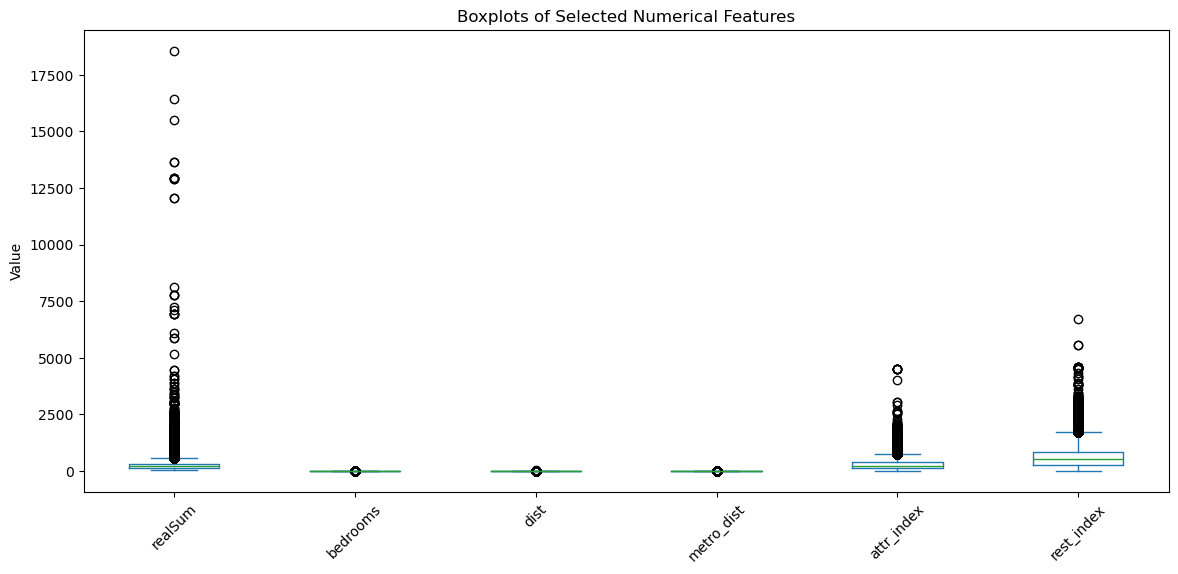

In [32]:
import matplotlib.pyplot as plt

eda_df[outlier_columns].plot(
    kind="box",
    figsize=(14, 6),
    rot=45
)

plt.title("Boxplots of Selected Numerical Features")
plt.ylabel("Value")
plt.show()

In [ ]:
eda_frames = []

for dataset_name, df in datasets.items():

    city, day_type = dataset_name.rsplit("_", 1)

    temp_df = df.copy() # Suppose we wrote: temp_df = df  Now both variables point to the same DataFrame. If we add:  temp_df["City"] = ... 
    #we've accidentally modified the original Bronze data stored in datasets. using .copy() creates an independent DataFrame.
    
    temp_df["City"] = city.title()
    temp_df["Day Type"] = day_type.title()

    eda_frames.append(temp_df)

eda_df = pd.concat(
    eda_frames,
    ignore_index=True
)

eda_df.head()

,Unnamed: 0,realSum,room_type,room_shared,room_private,person_capacity,host_is_superhost,multi,biz,cleanliness_rating,...,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm,lng,lat,City,Day Type
0,0,194.033698,Private room,False,True,2.0,False,1,0,10.0,...,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473,4.90569,52.41772,Amsterdam,Weekdays
1,1,344.245776,Private room,False,True,4.0,False,0,0,8.0,...,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928,4.90005,52.37432,Amsterdam,Weekdays
2,2,264.101422,Private room,False,True,2.0,False,0,1,9.0,...,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700,4.97512,52.36103,Amsterdam,Weekdays
3,3,433.529398,Private room,False,True,4.0,False,0,1,9.0,...,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565,4.89417,52.37663,Amsterdam,Weekdays
4,4,485.552926,Private room,False,True,2.0,True,0,0,10.0,...,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677,4.90051,52.37508,Amsterdam,Weekdays


In [38]:
eda_df.nlargest(10, "realSum")[
    ["realSum", "bedrooms", "person_capacity", "dist", "City"]
]

,realSum,bedrooms,person_capacity,dist,City
3590,18545.450285,1,2.0,1.196536,Athens
34803,16445.614689,1,2.0,4.602378,Paris
24348,15499.894165,3,3.0,0.269101,London
48380,13664.305916,1,2.0,2.239501,Vienna
50787,13656.358834,1,2.0,2.239486,Vienna
48215,12942.991375,1,4.0,1.497979,Vienna
30626,12937.275101,2,6.0,2.938307,London
31635,12929.513864,1,2.0,5.623463,London
25629,12886.239093,2,6.0,2.938326,London
25945,12886.239093,1,2.0,5.623461,London


# Categorical Feature Analysis

## 🎯 Objective

Analyze all categorical features to understand their distribution, identify dominant categories, detect unexpected values, and evaluate their potential business impact.

Unlike numerical variables, categorical variables describe groups or classifications rather than quantities.

Understanding these categories helps answer questions such as:

- What type of properties dominate Airbnb?
- Are Superhosts common?
- Are listings mostly private or shared?
- Do categorical features appear useful for price prediction?

---

## Why This Matters

Categorical variables often become dimensions in a data warehouse and filters in business intelligence dashboards.

Before designing the Silver and Gold layers, we need to understand:

- The possible values.
- Their frequencies.
- Their business significance.

This information will guide:

- Feature engineering.
- Star schema design.
- Power BI slicers.
- Business KPIs.

In [39]:
categorical_columns = [
    "room_type",
    "room_shared",
    "room_private",
    "host_is_superhost",
    "multi",
    "biz"
]
categorical_summary = []

for column in categorical_columns:

    value_counts = eda_df[column].value_counts()

    for value, count in value_counts.items():

        categorical_summary.append({
            "Column": column,
            "Category": value,
            "Count": count,
            "Percentage": round(
                count / len(eda_df) * 100,
                2
            )
        })

categorical_df = pd.DataFrame(categorical_summary)

display(categorical_df)

,Column,Category,Count,Percentage
0,room_type,Entire home/apt,32648,63.14
1,room_type,Private room,18693,36.15
2,room_type,Shared room,366,0.71
3,room_shared,False,51341,99.29
4,room_shared,True,366,0.71
5,room_private,False,33014,63.85
6,room_private,True,18693,36.15
7,host_is_superhost,False,38475,74.41
8,host_is_superhost,True,13232,25.59
9,multi,0,36642,70.86


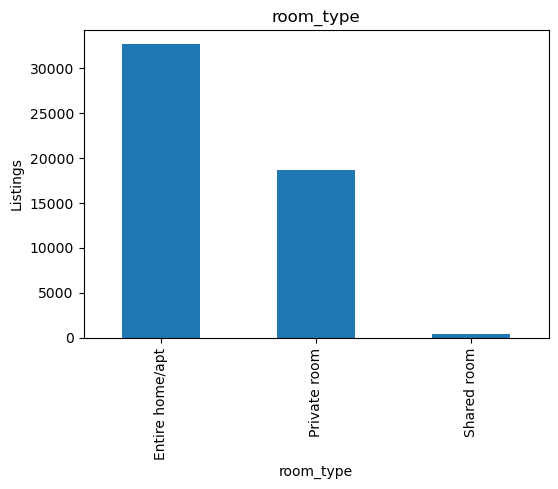

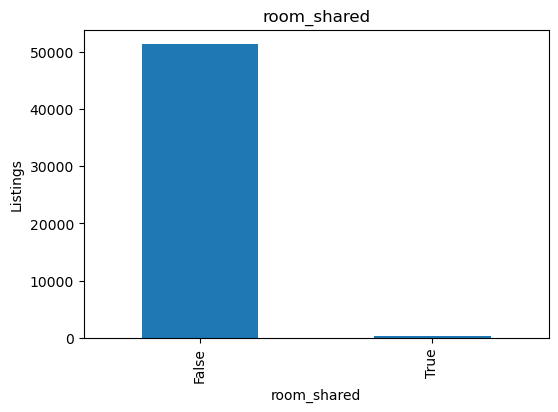

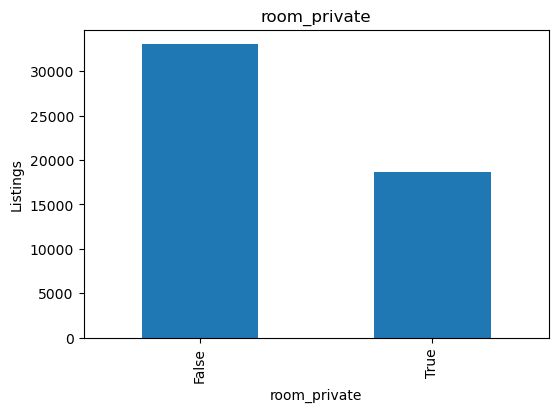

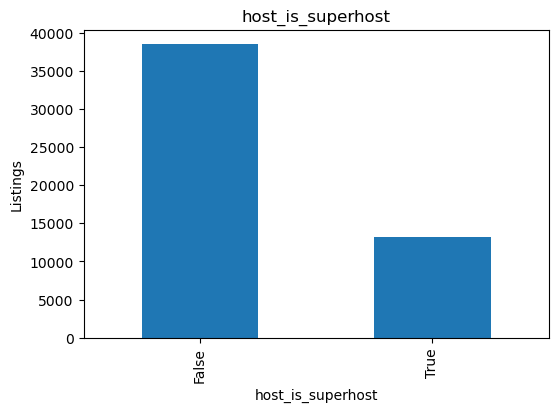

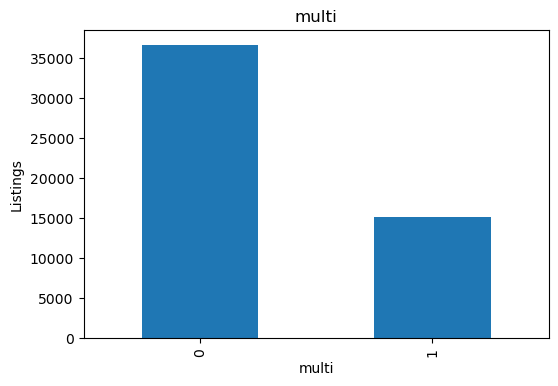

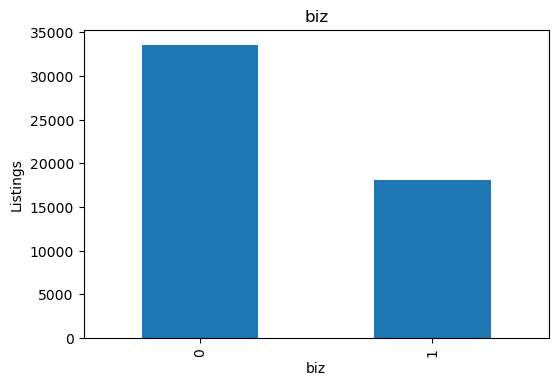

In [ ]:
for column in categorical_columns:

    plt.figure(figsize=(6,4))

    eda_df[column].value_counts().plot(
        kind="bar"
    )

    plt.title(column)

    plt.ylabel("Listings")

    plt.show()

# Correlation Analysis

## 🎯 Objective

Investigate the relationships between Airbnb listing price and the available numerical features.

Correlation analysis helps identify which variables appear to influence pricing and which have little explanatory power.

Rather than creating features based on intuition, we use statistical evidence to guide feature engineering.

---

## Why This Matters

One of the goals of this project is to determine whether the existing dataset sufficiently explains Airbnb pricing.

If strong relationships already exist, feature engineering may be enough.

If relationships are weak, additional enrichment (such as Selenium scraping) may be justified.

---

## Questions

During this phase we want to answer:

- Which numerical variables correlate most strongly with price?
- Are there variables with almost no relationship?
- Which engineered features are likely to improve the analysis?
- Does the dataset justify external enrichment?

In [41]:
correlation_columns = [
    "realSum",
    "person_capacity",
    "cleanliness_rating",
    "guest_satisfaction_overall",
    "bedrooms",
    "dist",
    "metro_dist",
    "attr_index",
    "attr_index_norm",
    "rest_index",
    "rest_index_norm"
]

correlation_matrix = (
    eda_df[correlation_columns]
    .corr(numeric_only=True)
    .round(2)
)

display(correlation_matrix)

,realSum,person_capacity,cleanliness_rating,guest_satisfaction_overall,bedrooms,dist,metro_dist,attr_index,attr_index_norm,rest_index,rest_index_norm
realSum,1.00,0.20,-0.01,-0.00,0.22,-0.04,-0.06,0.18,0.29,0.13,0.14
person_capacity,0.20,1.00,0.00,0.01,0.56,-0.13,-0.04,0.03,-0.05,0.04,0.04
cleanliness_rating,-0.01,0.00,1.00,0.71,0.03,-0.03,0.01,-0.03,-0.08,-0.03,-0.01
guest_satisfaction_overall,-0.00,0.01,0.71,1.00,0.05,-0.00,0.03,-0.05,-0.07,-0.07,-0.01
bedrooms,0.22,0.56,0.03,0.05,1.00,-0.01,0.04,-0.01,-0.06,-0.01,-0.06
dist,-0.04,-0.13,-0.03,-0.00,-0.01,1.00,0.56,-0.36,-0.24,-0.35,-0.47
metro_dist,-0.06,-0.04,0.01,0.03,0.04,0.56,1.00,-0.17,-0.22,-0.14,-0.26
attr_index,0.18,0.03,-0.03,-0.05,-0.01,-0.36,-0.17,1.00,0.71,0.85,0.54
attr_index_norm,0.29,-0.05,-0.08,-0.07,-0.06,-0.24,-0.22,0.71,1.00,0.53,0.47
rest_index,0.13,0.04,-0.03,-0.07,-0.01,-0.35,-0.14,0.85,0.53,1.00,0.62


In [45]:
#Price vs Everything Else

price_correlation = (
    correlation_matrix["realSum"]
    .drop("realSum")
    .sort_values(ascending=False)
)

display(price_correlation)

attr_index_norm               0.29
bedrooms                      0.22
person_capacity               0.20
attr_index                    0.18
rest_index_norm               0.14
rest_index                    0.13
guest_satisfaction_overall   -0.00
cleanliness_rating           -0.01
dist                         -0.04
metro_dist                   -0.06
Name: realSum, dtype: float64

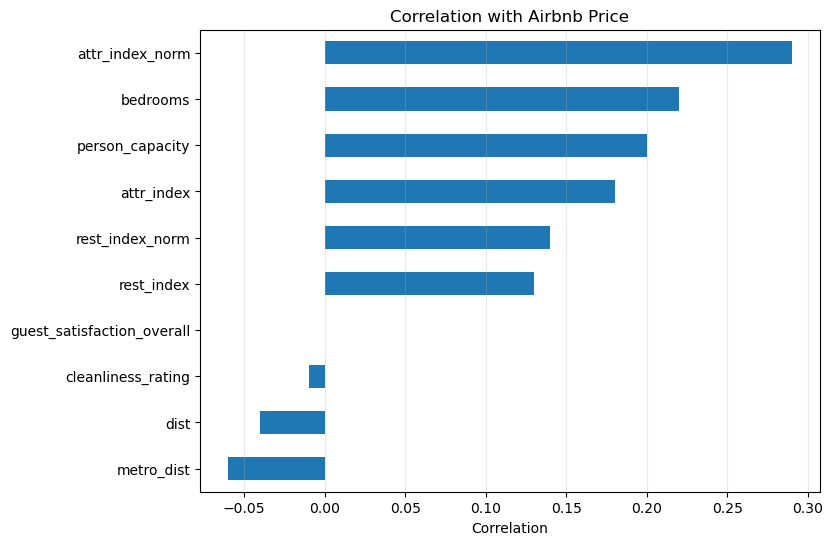

In [46]:
price_correlation.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Correlation with Airbnb Price")
plt.xlabel("Correlation")
plt.grid(axis="x", alpha=0.3)

plt.show()

Correlation analysis revealed that the strongest relationship with price was only 0.29, indicating that the available features explain only a limited portion of price variation. Therefore, additional features were collected through web scraping to improve the analytical value of the dataset.

The numerical features exhibit weak linear relationships with price. Additional analysis of categorical features and external enrichment is therefore justified.

## How does the market behave

# Business Segmentation Analysis

## 🎯 Objective

Investigate how Airbnb prices differ across important business segments.

While correlation analysis measures linear relationships between numerical variables, many important business features are categorical.

This phase analyzes pricing across different market segments to uncover patterns that cannot be captured through correlation alone.

---

## Why This Matters

Business users rarely ask for correlation coefficients.

Instead, they ask questions such as:

- Which city is the most expensive?
- Are weekends more expensive?
- Do Superhosts charge higher prices?
- Are entire homes significantly more expensive than private rooms?

Answering these questions provides actionable business insights and helps identify valuable features for the Silver layer and dimensions for the Gold data warehouse.

---

## Questions

During this phase we want to answer:

- Which city has the highest average Airbnb price?
- Do weekend listings cost more?
- Does room type significantly affect price?
- Do Superhosts charge more?
- Are business hosts more expensive?

In [47]:
#Average Price by City
city_price = (
    eda_df
    .groupby("City")["realSum"]
    .agg(["mean", "median", "count"])
    .round(2)
    .sort_values("mean", ascending=False)
)

display(city_price)

,mean,median,count
City,,,
Amsterdam,573.11,460.24,2080
Paris,392.53,317.60,6688
London,362.47,261.29,9993
Barcelona,293.75,208.30,2833
Berlin,244.58,191.18,2484
Vienna,241.58,208.49,3537
Lisbon,238.21,225.38,5763
Rome,205.39,182.59,9027
Budapest,176.51,152.98,4022


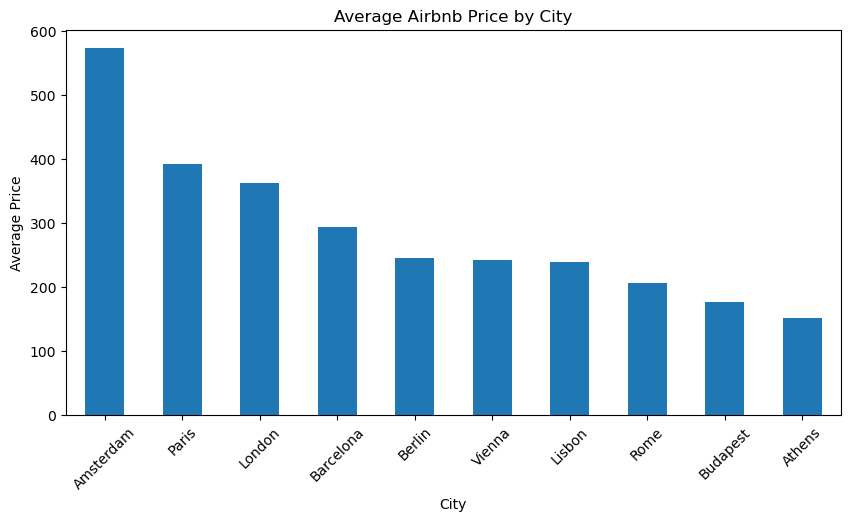

In [48]:
city_price["mean"].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Airbnb Price by City")
plt.ylabel("Average Price")
plt.xticks(rotation=45)

plt.show()

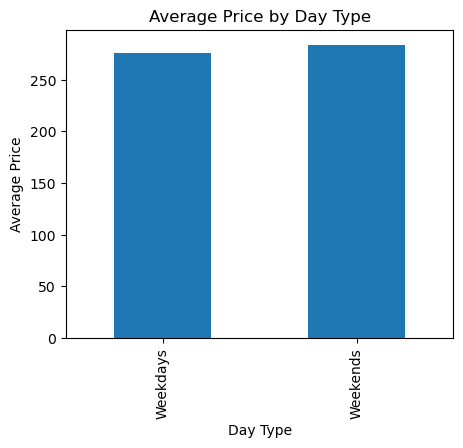

In [51]:
day_price = (
    eda_df
    .groupby("Day Type")["realSum"]
    .agg(["mean", "median", "count"])
    .round(2)
)

day_price["mean"].plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Average Price by Day Type")
plt.ylabel("Average Price")

plt.show()

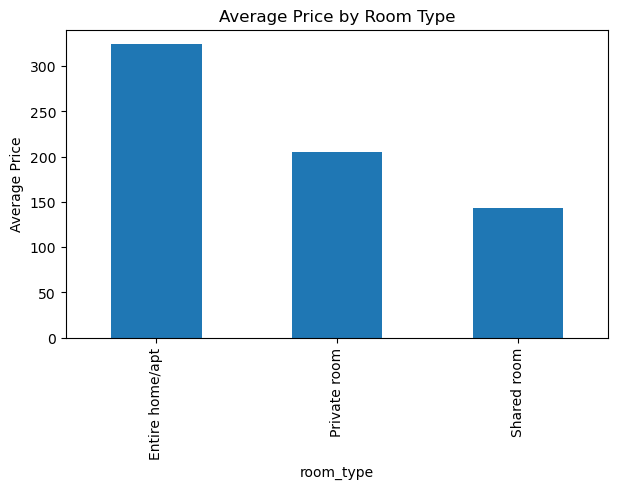

In [52]:
room_price = (
    eda_df
    .groupby("room_type")["realSum"]
    .agg(["mean", "median", "count"])
    .round(2)
    .sort_values("mean", ascending=False)
)
room_price["mean"].plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Average Price by Room Type")
plt.ylabel("Average Price")

plt.show()

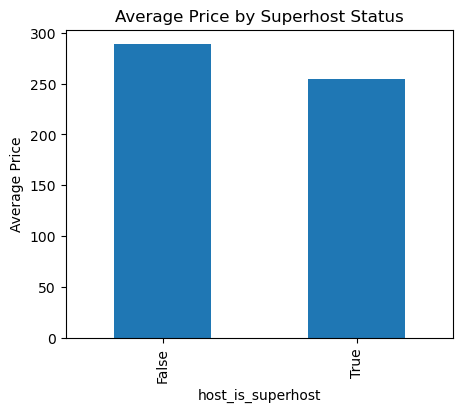

In [53]:
superhost_price = (
    eda_df
    .groupby("host_is_superhost")["realSum"]
    .agg(["mean", "median", "count"])
    .round(2)
)

superhost_price["mean"].plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Average Price by Superhost Status")
plt.ylabel("Average Price")

plt.show()

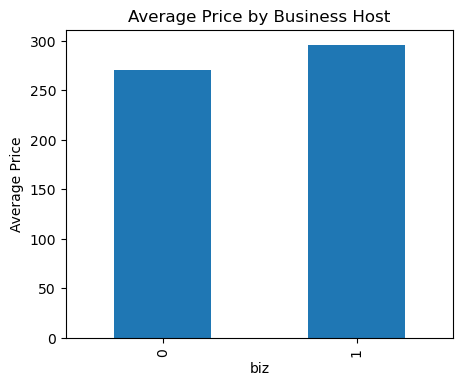

In [54]:
business_price = (
    eda_df
    .groupby("biz")["realSum"]
    .agg(["mean", "median", "count"])
    .round(2)
)

business_price["mean"].plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Average Price by Business Host")
plt.ylabel("Average Price")

plt.show()

## Business Segmentation Interpretation

Business segmentation analysis revealed several important pricing patterns that were not visible through numerical correlation analysis alone.

While numerical features exhibited relatively weak linear relationships with price, categorical variables showed clear differences between market segments.

These findings demonstrate that segmentation variables play an important role in explaining Airbnb pricing and should be preserved as dimensions within the data warehouse.

- Price depends heavily on geography.

- Weekend prices are slightly higher Not dramatically But consistently. Business conclusion Demand increases slightly during weekends.

- Room Type is one of the strongest pricing drivers


- Superhosts are actually slightly cheaper Not more expensive.

Possible explanations

Maybe Superhosts compete more aggressively or offer better value or exist in cheaper cities

Notice

Correlation cannot answer WHY.

Only

"there is a difference."

- Business hosts charge more Makes sense.

Professional property managers. Premium listings.


---------------------------------------------------------------------------
The numerical variables have weak linear relationships with price.

However,

categorical variables such as

City

Room Type

Business Host

show clear pricing differences.

Therefore,

the current dataset already provides valuable explanatory information,

but additional enrichment may still improve the analysis by capturing listing characteristics that are currently unavailable.

In [55]:
eda_df.columns.tolist()

['Unnamed: 0',
 'realSum',
 'room_type',
 'room_shared',
 'room_private',
 'person_capacity',
 'host_is_superhost',
 'multi',
 'biz',
 'cleanliness_rating',
 'guest_satisfaction_overall',
 'bedrooms',
 'dist',
 'metro_dist',
 'attr_index',
 'attr_index_norm',
 'rest_index',
 'rest_index_norm',
 'lng',
 'lat',
 'City',
 'Day Type']